# Advanced Financial Computation with Convolution and Correlation

In the previous notebook, we covered:
- Time-series data
- Computation with NumPy
- Basic filtering techniques and moving averages

In this notebook, we'll explore more advanced concepts:
- Convolution and its applications in finance
- Window functions and their impact on filtering
- Correlation between financial signals
- Exponential Moving Average (EMA) implementation

This material builds on the foundations laid in the first notebook while introducing more sophisticated signal processing techniques.

In [ ]:
# Run this cell first to install required packages
try:
    # Check if we're running in Colab
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing required packages...")
    !pip install -q numpy matplotlib scipy wavio requests
except ImportError:
    IN_COLAB = False
    print("Running in local Jupyter environment.")

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import os
import IPython.display as ipd
print("Setup complete!")

Running in Google Colab. Installing required packages...
Setup complete!


# Financial and Audio Data Sources

Based on the book `Numpy for Beginners`: https://learning.oreilly.com/library/view/numpy-beginners/9781785281969/

This notebook uses:
1. Financial data: 5 years of S&P 500 data, up to Feb 2018
2. Audio data: Impulse responses and sample recordings for convolution demonstration

> Stock market data can be interesting to analyze and as a further incentive, strong predictive models can have large financial payoff. The amount of financial data on the web is seemingly endless. A large and well structured dataset on a wide array of companies can be hard to come by. Here I provide a dataset with historical stock prices (last 5 years) for all companies currently found on the S&P 500 index.

## Data Files
All files are hosted on Google Drive and will be downloaded automatically:
- Financial data: data.csv, AAPL_data.csv, MSFT_data.csv, AMZN_data.csv
- Audio files: minster1_omni_48k.wav (impulse response), rec.wav (speech recording)

Derived [online SMA algorithm](https://en.wikipedia.org/wiki/Online_algorithm).

$$S_{n+1} = S_n + \frac{x_{n+1}-S_n}{n+1} $$

[Notes from our calculations.](https://drive.google.com/file/d/1oPKaWj3DX0W9EIktJvNhdsL6x5QIvNeD/view?usp=drive_link)

# Next Steps: Advanced Signal Processing for Finance

In this notebook, we've covered several key concepts connecting signal processing and financial analysis:

1. **Convolution**:
   - Applied to audio signals to transform a speech recording with venue acoustics
   - Used for financial moving averages by convolving price data with window functions

2. **Window Functions**:
   - Explored various windows (rectangular, Hamming, Hanning) and their effect on filtering
   - Saw how different windows affect the smoothness and lag of financial indicators

3. **Correlation**:
   - Calculated correlation between different stock returns
   - Visualized correlation matrices for portfolio analysis

## Future Directions

Here are some advanced topics to explore next:

- **Spectral Analysis**: Analyzing the frequency components of financial time series
- **Wavelet Transforms**: Multi-resolution analysis of financial data to identify patterns at different time scales
- **Kalman Filters**: More sophisticated state estimation techniques beyond simple moving averages
- **Machine Learning**: Using signal features as inputs to predictive models
- **High-Frequency Data**: Applying these techniques to tick-level data

The signal processing techniques we've learned serve as powerful tools for extracting meaningful patterns from financial data and can form the basis for more sophisticated trading strategies.

## A more convoluted approach


The convolution operation can be used it for [filtering images](http://graphics.stanford.edu/courses/cs148-10-summer/docs/04_imgproc.pdf), [solving the diff eq repsenting our circuits](http://www.ee.ic.ac.uk/pcheung/teaching/ee2_signals/Lecture%205%20-%20Convolution.pdf) or as the [building blocks of CNN](https://en.wikipedia.org/wiki/Convolutional_neural_network#Building_blocks).

Convolution allows our signal to be modeled after another signal (impulse response).

We can create echos, reverb, shift pitch, etc.

## Math

The operation is defined for 2 discrete, finite functions as:

$$(f* g)[n]=\sum_{m=-M}^M f[n-m]g[m]$$

where $f$ and $g$ can be complex valued.

You may have seen [this video](https://www.youtube.com/watch?v=ZPEBYXrfVQw) or a similar one i.e., PS5 or a [3D audio demo](https://www.youtube.com/watch?v=s3eOuqAmLAA&feature=youtu.be).

## Why would we convolve 2 signals?

Circuits: Convolution can give us the "output" of the circuit given the input and system parameters.

But, in many real-world applications, we don't have access to the mathematical model.

We will experiment with audio here and soon with images.

For instance, we may record our song in the studio, but want it to sound like it was recorded in a different venue.

$$ Signal * Venue \rightarrow \text{Song at Venue}$$

What do we need for our Venue model?

- Mathematical model, such as a difference equation

- Impulse recording (fast and strong disturbance)

If we can "shock" the system, we can record its response to this sudden change.

## Understanding Convolution: More Than Just Math

The convolution formula $$(f* g)[n]=\sum_{m=-M}^M f[n-m]g[m]$$ might look intimidating, but it represents a process of 'blending' or 'filtering' one signal (f) with another (g).

**Think of it like applying a filter:**

Imagine you have a list of numbers (your signal `f`), and you want to smooth them out by averaging a few neighbors. You use a 'filter' (your kernel `g`, which for a simple moving average is just a set of equal weights). Convolution is the process of sliding this filter `g` across your signal `f`, position by position, and at each position, calculating a weighted sum of the `f` values under the filter, using the weights from `g`.

**Visualizing the Process:**

Consider two small arrays: `f = [1, 2, 3, 4]` and `g = [0.5, 1]`.

To calculate the convolution at a specific point, we flip `g` (`[1, 0.5]`) and slide it over `f`. Then, we multiply the overlapping elements and sum them up.

*   **Step 1 (n=0):** No overlap yet, or partial overlap depending on definition boundaries. For 'full' convolution, we start when the first element of the flipped kernel aligns with the first element of the signal. Let's consider the output length of N+M-1.
    *   Align `[1, 0.5]` with `[1, 2, 3, 4]`: `[0.5]` overlaps with `[1]`. Output term: `0.5 * 1 = 0.5`.
*   **Step 2 (n=1):** Slide flipped `g` one step right.
    *   Align `[1, 0.5]` with `[1, 2, 3, 4]`: `[1, 0.5]` overlaps with `[1, 2]`. Output term: `1 * 1 + 0.5 * 2 = 1 + 1 = 2`.
*   **Step 3 (n=2):** Slide flipped `g` one step right.
    *   Align `[1, 0.5]` with `[1, 2, 3, 4]`: `[1, 0.5]` overlaps with `[2, 3]`. Output term: `1 * 2 + 0.5 * 3 = 2 + 1.5 = 3.5`.
*   **Step 4 (n=3):** Slide flipped `g` one step right.
    *   Align `[1, 0.5]` with `[1, 2, 3, 4]`: `[1, 0.5]` overlaps with `[3, 4]`. Output term: `1 * 3 + 0.5 * 4 = 3 + 2 = 5`.
*   **Step 5 (n=4):** Slide flipped `g` one step right.
    *   Align `[1, 0.5]` with `[1, 2, 3, 4]`: `[1]` overlaps with `[4]`. Output term: `1 * 4 = 4`.

The resulting convolved signal (full mode) is approximately `[0.5, 2, 3.5, 5, 4]`. (Note: The exact output depends on the convolution mode 'full', 'same', or 'valid'. The example above loosely follows the 'full' mode intuition).

**Relevance to Computer Science:**

Convolution is a fundamental operation in many areas of computer science:
*   **Image Processing:** Filters like blurring, sharpening, and edge detection are implemented using convolution kernels applied to pixel data.
*   **Signal Processing:** Filtering, smoothing, and system analysis in audio, communications, and other domains.
*   **Deep Learning:** Convolutional Neural Networks (CNNs) use convolution layers to automatically learn hierarchical features in data like images and sequences.

This operation allows us to transform a signal based on the characteristics of a 'filter' or 'system response', revealing underlying patterns or modifying the signal's properties.


### Where can find these Impulse Responses (IR)?

> York Minster is the largest medieval gothic cathedral in the UK and one of the finest in Europe, built between the 12th and 15th centuries on the foundations of the previous Norman church that was in turn constructed on the foundations of the original Roman fortress. It is approximately 160m long, 76m wide and 27m high to the vaulted ceiling, constructed predominantly of stone with extensive, large panels of stained glass windows. Its beautiful acoustic and setting make it a sought after and highly popular music performance venue.

[Openairlib](https://openairlib.net/?page_id=797)

In [ ]:
import wave
import sys
import matplotlib.pylab as plt
from scipy.io.wavfile import read, write
import numpy as np
from scipy import signal
import requests

# Function to load any file (financial or audio) from Google Drive
def load_file_from_gdrive(file_id, filename, file_type='csv'):
    """
    Load file from Google Drive (works in both Colab and regular notebooks)

    Parameters:
    -----------
    file_id : str
        Google Drive file ID (from the shared link)
    filename : str
        Filename to save locally
    file_type : str
        Type of file ('csv' or 'wav')

    Returns:
    --------
    Varies based on file_type:
        - csv: tuple of numpy arrays (closing_prices, volumes)
        - wav: tuple of (sample_rate, audio_data)
    """
    try:
        # First check if file already exists locally
        if os.path.exists(filename):
            print(f"Loading {filename} from local directory...")
            if file_type == 'csv':
                if filename == 'data.csv':
                    return np.loadtxt(filename, delimiter=',', usecols=(6,7), unpack=True)
                else:
                    return np.loadtxt(filename, delimiter=',', usecols=(4,5), unpack=True, skiprows=1)
            elif file_type == 'wav':
                from scipy.io import wavfile
                return wavfile.read(filename)

        # Check if running in Colab
        try:
            in_colab = 'google.colab' in str(get_ipython())
        except:
            in_colab = False

        if in_colab:
            # Use gdown in Colab (simpler approach)
            print(f"Downloading {filename} from Google Drive...")
            !pip install -q gdown
            !gdown {file_id} -O {filename}
        else:
            # For regular Jupyter notebooks, download directly using requests
            print(f"Downloading {filename} from Google Drive...")

            # Create the download URL from the file ID
            url = f"https://drive.google.com/uc?id={file_id}"

            # Download the file
            response = requests.get(url)
            with open(filename, 'wb') as f:
                f.write(response.content)

        # Load and return the data based on file type
        print(f"Successfully downloaded {filename}")
        if file_type == 'csv':
            if filename == 'data.csv':
                return np.loadtxt(filename, delimiter=',', usecols=(6,7), unpack=True)
            else:
                return np.loadtxt(filename, delimiter=',', usecols=(4,5), unpack=True, skiprows=1)
        elif file_type == 'wav':
            from scipy.io import wavfile
            return wavfile.read(filename)

    except Exception as e:
        print(f"Error loading data: {e}")

        # Fallback to original path if download fails
        fallback_path = '/home/memo/public/eaix/'
        if os.path.exists(fallback_path + filename):
            print(f"Falling back to local path: {fallback_path}")
            if file_type == 'csv':
                if filename == 'data.csv':
                    return np.loadtxt(fallback_path + filename, delimiter=',', usecols=(6,7), unpack=True)
                else:
                    return np.loadtxt(fallback_path + filename, delimiter=',', usecols=(4,5), unpack=True, skiprows=1)
            elif file_type == 'wav':
                from scipy.io import wavfile
                return wavfile.read(fallback_path + filename)

        # If all else fails, raise the error
        raise FileNotFoundError(f"Could not load {filename}. Please check your internet connection or file path.")

# Dictionary of file IDs for easy access
file_ids = {
    'data.csv': '1jG7Ml-hZp3LwYrbDe3asgiyPI5oGM6n4',
    'AAPL_data.csv': '1uBUC0aQSmTPdHFJ05fv6aZGu2MGw3EAW',
    'MSFT_data.csv': '1314rW_N3np8Mh8g74TPwSUBfI1I7lfA9',
    'AMZN_data.csv': '1fnjsjVdBqHRPHjMNST6i-bY2TFA7_iZM',
    'minster1_omni_48k.wav': '1SkNBL8ylsxfWui1JKTljym6y6l26Rsxs',
    'rec.wav': '1wwl2xxCcSGOX6QgBcK72saQ_uE7QAjol'
}

# https://drive.google.com/file/d/1SkNBL8ylsxfWui1JKTljym6y6l26Rsxs/view?usp=sharing
# https://drive.google.com/file/d/1wwl2xxCcSGOX6QgBcK72saQ_uE7QAjol/view?usp=sharing

print("Data loading function ready. Use load_file_from_gdrive(file_id, filename, file_type) to load files.")

Data loading function ready. Use load_file_from_gdrive(file_id, filename, file_type) to load files.


## Audio Examples for Convolution Demonstration

Let's listen to our audio files before applying convolution. This will help us understand how convolution transforms signals in the audio domain before we apply similar concepts to financial data.

In [ ]:
# Load and play the impulse response (IR) from York Minster cathedral
# An impulse response captures the acoustic characteristics of a venue
ir_file = 'minster1_omni_48k.wav'
ir_id = file_ids.get(ir_file)

# Load the IR file
ir_rate, ir_data = load_file_from_gdrive(ir_id, ir_file, 'wav')

# Display the audio player
print("York Minster Cathedral Impulse Response:")
display(ipd.Audio(ir_data, rate=ir_rate))

Downloading...
From: https://drive.google.com/uc?id=1SkNBL8ylsxfWui1JKTljym6y6l26Rsxs
To: /content/minster1_omni_48k.wav
100% 1.44M/1.44M [00:00<00:00, 115MB/s]
Successfully downloaded minster1_omni_48k.wav
York Minster Cathedral Impulse Response:


/tmp/ipython-input-3521916341.py:74: WavFileWarning: Chunk (non-data) not understood, skipping it.
  return wavfile.read(filename)


In [ ]:
# Load and play the speech recording
speech_file = 'rec.wav'
speech_id = file_ids.get(speech_file)

# Load the speech file
speech_rate, speech_data = load_file_from_gdrive(speech_id, speech_file, 'wav')

# Display the audio player
print("Original Speech Recording:")
display(ipd.Audio(speech_data, rate=speech_rate))

Downloading...
From: https://drive.google.com/uc?id=1wwl2xxCcSGOX6QgBcK72saQ_uE7QAjol
To: /content/rec.wav
100% 660k/660k [00:00<00:00, 108MB/s]
Successfully downloaded rec.wav
Original Speech Recording:


In [ ]:
# We'll create this output file after performing convolution
print("We'll create the convolved output (speech in cathedral) later in the notebook")

We'll create the convolved output (speech in cathedral) later in the notebook


In [ ]:
# Process the impulse response for convolution
# We need to convert it to 1D numpy array with float64 type
irf = ir_data.astype(np.float64)

# If the impulse response is stereo, take just the first channel
if len(irf.shape) > 1:
    irf = irf[:, 0]

print(f"Impulse response shape: {irf.shape}, dtype: {irf.dtype}")

Impulse response shape: (480000,), dtype: float64


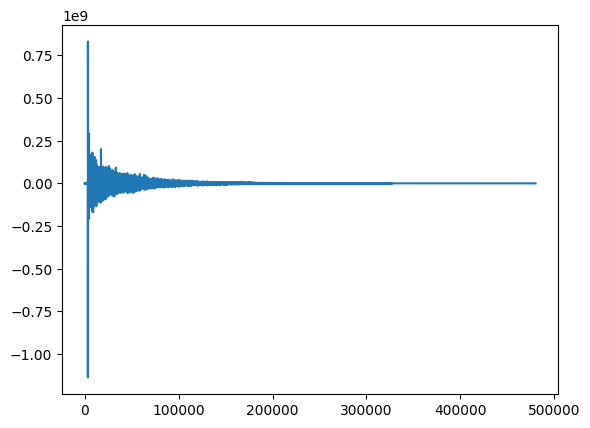

In [ ]:
plt.plot(irf)

## Math

The operation is defined for 2 discrete, finite functions as:

$$(f* g)[n]=\sum_{m=-M}^M f[n-m]g[m]$$

where $f$ and $g$ can be complex valued.

See [link](https://www.youtube.com/watch?v=KuXjwB4LzSA)

Speech recording shape: (329389,), dtype: float64


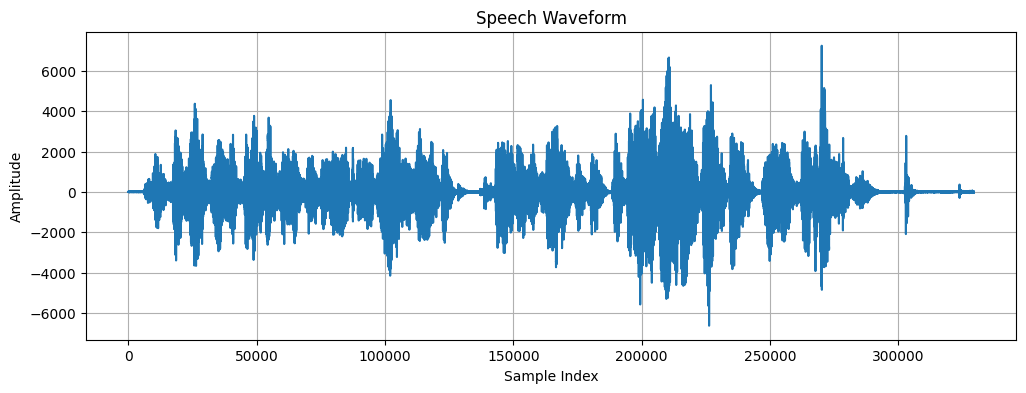

In [ ]:
# Process the speech recording for convolution
spf = speech_data.astype(np.float64)

# If the speech is stereo, take just the first channel
if len(spf.shape) > 1:
    spf = spf[:, 0]

# We'll trim some samples from the beginning to remove any silence
spf = spf[750:]

print(f"Speech recording shape: {spf.shape}, dtype: {spf.dtype}")

# Plot the waveform
plt.figure(figsize=(12, 4))
plt.plot(spf)
plt.title("Speech Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [ ]:
# Perform convolution using two different methods
import time

# Method 1: Time Domain Convolution
start_time = time.time()

# run time domain convolution (slower)
conv = np.convolve(spf, irf)
time_domain_time = time.time() - start_time
print(f"Time domain convolution took {time_domain_time:.4f} seconds")



Time domain convolution took 101.8482 seconds


In [ ]:
# Method 2: Frequency Domain Convolution (using FFT)
start_time = time.time()
fconv = signal.fftconvolve(spf, irf)
freq_domain_time = time.time() - start_time
print(f"Frequency domain convolution took {freq_domain_time:.4f} seconds")



Frequency domain convolution took 0.1144 seconds


In [ ]:
# Compare sizes
print(f"Output signal shape: {fconv.shape}")



Output signal shape: (809388,)


In [ ]:
# Explanation of why FFT-based convolution is faster for large signals
print("\nWhy is FFT-based convolution typically faster?")
print("- Time domain: O(n²) - each output sample requires n multiplications")
print("- Frequency domain: O(n log n) - FFT transforms are O(n log n), multiplication in frequency domain is O(n)")
print("- For large signals, O(n log n) is much faster than O(n²)")


Why is FFT-based convolution typically faster?
- Time domain: O(n²) - each output sample requires n multiplications
- Frequency domain: O(n log n) - FFT transforms are O(n log n), multiplication in frequency domain is O(n)
- For large signals, O(n log n) is much faster than O(n²)


In [ ]:
# Normalize and save the output
# We normalize by dividing by the sum to avoid clipping
out = fconv / np.max(np.abs(fconv)) * 0.9  # Scale to 90% of maximum to avoid clipping

# Convert to int16 format for audio file
out = (out * 32767).astype(np.int16)

# Save the file
from scipy.io import wavfile
wavfile.write('outputfconv.wav', speech_rate, out)

# Play the result
print("Convolved Output (Speech in York Minster Cathedral):")
display(ipd.Audio(out, rate=speech_rate))



Convolved Output (Speech in York Minster Cathedral):



What we've done:
1. Taken a dry speech recording
2. Convolved it with the impulse response of York Minster Cathedral
3. Created the sound of that speech as if it were recorded in the cathedral


In [ ]:
# What we've accomplished:
print("\nWhat we've done:")
print("1. Taken a dry speech recording")
print("2. Convolved it with the impulse response of York Minster Cathedral")
print("3. Created the sound of that speech as if it were recorded in the cathedral")

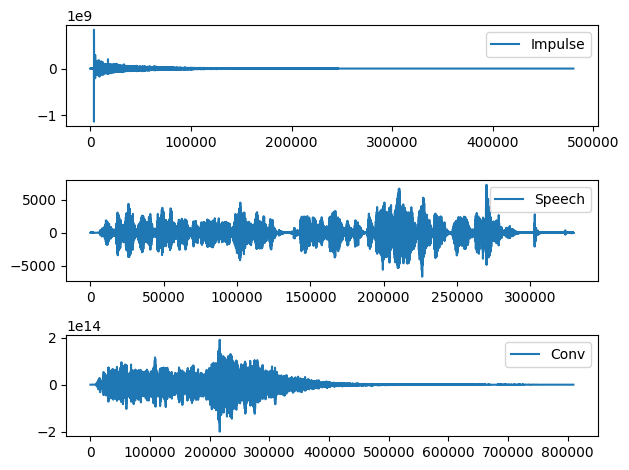

In [ ]:
#plot it all
plt.subplot(311)
plt.plot(irf, label='Impulse')
plt.legend(loc="upper right")
plt.subplot(312)
plt.plot(spf, label='Speech')
plt.legend(loc="upper right")
plt.subplot(313)
plt.plot(fconv, label='Conv')
plt.legend(loc="upper right")
# plt.plot(out)
plt.tight_layout() #fix plt formatting
plt.show()

Let's go back to $.

You may now realize that SMA might be approached in a similar way!


# Applying Convolution to Financial Data

Now that we understand convolution with audio signals, let's apply the same concept to financial data.
We'll use convolution to implement a moving average filter on stock price data.

In [ ]:
# Load financial data from Google Drive
data_file = 'data.csv'
data_id = file_ids.get(data_file)

# Load the data
c, v = load_file_from_gdrive(data_id, data_file, 'csv')

print(f"Loaded financial data with {len(c)} data points")
print(f"First 5 closing prices: {c[:5]}")
print(f"First 5 trading volumes: {v[:5]}")

Downloading...
From: https://drive.google.com/uc?id=1jG7Ml-hZp3LwYrbDe3asgiyPI5oGM6n4
To: /content/data.csv
100% 1.61k/1.61k [00:00<00:00, 6.95MB/s]
Successfully downloaded data.csv
Loaded financial data with 30 data points
First 5 closing prices: [336.1  339.32 345.03 344.32 343.44]
First 5 trading volumes: [21144800. 13473000. 15236800.  9242600. 14064100.]


Weights [0.2 0.2 0.2 0.2 0.2]


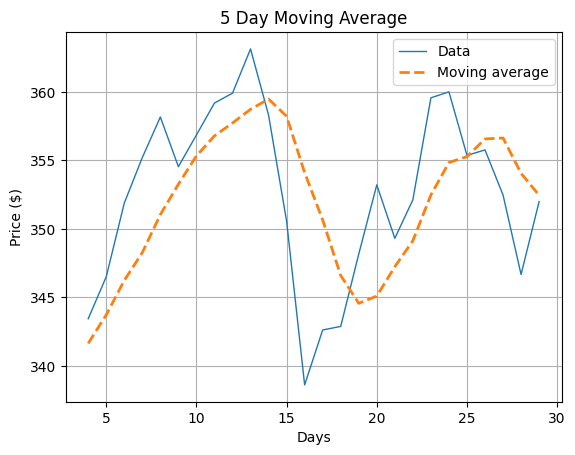

In [ ]:
#Window length:
N = 5

#uniform weights
weights = np.ones(N) / N
print("Weights", weights)

sma = np.convolve(weights, c)[N-1:-N+1]

t = np.arange(N - 1, len(c))
plt.plot(t, c[N-1:], lw=1.0, label="Data")
plt.plot(t, sma, '--', lw=2.0, label="Moving average")
plt.title(str(N)+" Day Moving Average")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.grid()
plt.legend()

## Exponential Moving Average

What if we want to weight the more recent samples more and "forget" the older samples?

[Overview](https://en.wikipedia.org/wiki/Moving_average#Exponential_moving_average)

We can implement it using any of the previous methods:
- Using a `for` loop for windowing
- Online algorithm
- Convolution

In [ ]:
x = np.arange(5)
print("Exp", np.exp(x))
print("Linspace", np.linspace(-1, 0, 5))

Exp [ 1.          2.71828183  7.3890561  20.08553692 54.59815003]
Linspace [-1.   -0.75 -0.5  -0.25  0.  ]


In [ ]:
# Calculate weights
N = 5
weights = np.exp(np.linspace(-1., 0., N))

# Normalize weights
weights /= weights.sum()
print("Weights", weights)

Weights [0.11405072 0.14644403 0.18803785 0.24144538 0.31002201]


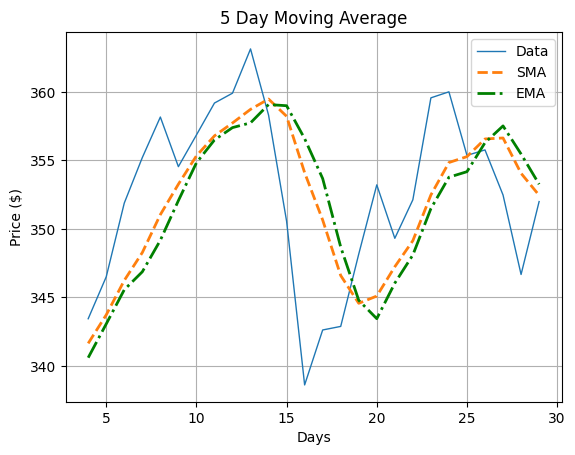

In [ ]:
ema = np.convolve(weights, c)[N-1:-N+1]

t = np.arange(N - 1, len(c))
plt.plot(t, c[N-1:], lw=1.0, label="Data")
plt.plot(t, sma, '--', lw=2.0, label="SMA")
plt.plot(t, ema, '-.', lw=2.0, c='g', label="EMA")
plt.title(str(N)+" Day Moving Average")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.grid()
plt.legend()

## Ex

Implement the recursive/online EMA as defined at [Wikipedia](https://en.wikipedia.org/wiki/Moving_average#Exponential_moving_average).

$$S_{n} = \alpha \cdot x_n + (1- \alpha) \cdot S_{n-1} $$

Try the recommended formula for our weights: $$\alpha = \frac{2}{N+1}$$

Q: How does it compare to the prev. EMA weights?

Q: What would be the length of the resulting array?

In [ ]:
# Your code for recursive EMA goes here.
# Copy your online SMA/ weights to get started.
# Copy your online SMA to get started.
#Hint: use for-loop and set S_0 = c_0
N=5
# a=?
# emaon = ?


NameError: name 'emaon' is not defined

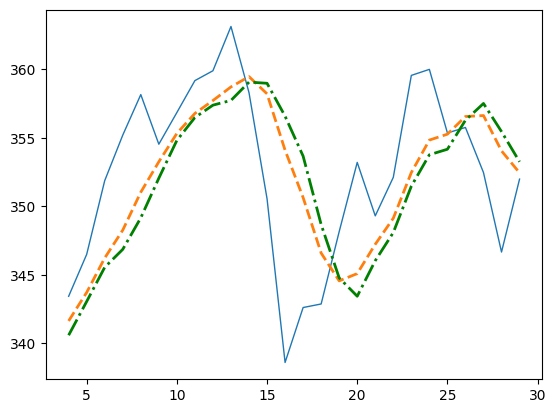

In [ ]:
ema = np.convolve(weights, c)[N-1:-N+1]

t = np.arange(N - 1, len(c))
plt.plot(t, c[N-1:], lw=1.0, label="Data")
plt.plot(t, sma, '--', lw=2.0, label="SMA")
plt.plot(t, ema, '-.', lw=2.0, c='g', label="EMA")
plt.plot(t, emaon[N-1:], '.', lw=2.0, c='r', label="EMAonl")

plt.title(str(N)+" Day Moving Average")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.grid()
plt.legend()


## Windowing

We are currently using a linear window (picking all values  within the window range evenly).

If we look at this operation in frequency domain, we notice that the sharp edges of this window may cause artifacts.

Based on the application and signal characteristics, we may need a more speciliazed window (speech vs music vs imaging). Some of the popular ones are coded in NumPy and shown below.

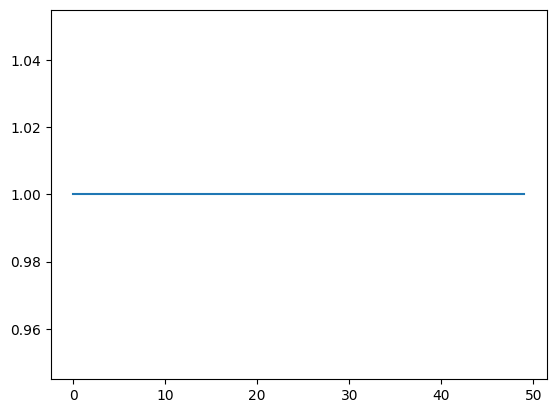

In [ ]:
x = 50
# x = N
window = np.ones(x)
# window = np.blackman(x)
# window = np.hamming(x)
# window =np.hanning(x)
#Based on the Bessel function
# window = np.kaiser(x, 14) #need Beta

plt.plot(window)
plt.show()

We can then use the window coeff as weights to smooth our values:

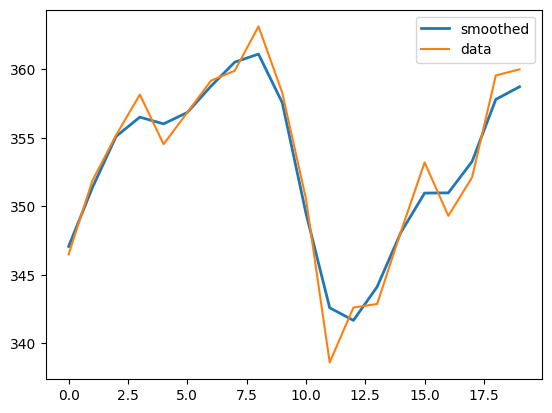

In [ ]:
x=5
# pick a window here!
window =np.hanning(x)

smoothed = np.convolve(window/window.sum(),c, mode='same')

plt.plot(smoothed[N:-N], lw=2, label="smoothed")
plt.plot(c[N:-N], label="data")
plt.legend(loc='best')
plt.show()

## Convolution vs Correlation

Many times, we need to know if two signals are similar.

**Correlation** could help us measure this similarity, regardless of a **time lag**.

We assume highly correlated signals to be related (in some way).

We can use correlation to see if two stocks are similar, finding rivals or pedicting response.

We can also use it to compare a (noisy) measurement to a reference signal, like listening for dial tones.

While its application is quiet different than convolution, it is implemented similarly (mathematically and programatically).

Many people confuse these two terms.

See the visual comparaison of these operations [here](https://en.wikipedia.org/wiki/Convolution)

## Understanding Correlation and Cross-Correlation

While convolution tells us how one signal filters or modifies another, **correlation** measures the **similarity** between two signals.

**Correlation (Zero Lag):**

When we talk about simple correlation (like the correlation matrix we saw), we're usually looking at how much two signals move together *at the same time*. A high positive correlation means they tend to go up and down together. A high negative correlation means one goes up when the other goes down. A correlation near zero means there's little to no linear relationship.

**Analogy:** Imagine comparing the daily step counts of two friends. High correlation means they tend to have high step counts on the same days and low step counts on the same days.

**Cross-Correlation (with Time Lag):**

**Cross-correlation** takes this a step further by measuring similarity as a function of a **time lag** between the signals. It helps us see if one signal is similar to a *shifted* version of the other. This is useful for finding if one signal *leads* or *lags* another.

The cross-correlation at a specific lag `k` is essentially the correlation between the first signal and the second signal shifted by `k` positions.

**Analogy:** Now, imagine comparing the step counts again, but you suspect Friend A's activity on one day influences Friend B's activity the *next* day. You'd calculate the cross-correlation with a lag of 1 day to see if Friend A's steps on Day 1 correlate with Friend B's steps on Day 2. Finding the lag that gives the maximum cross-correlation can reveal a potential lead-lag relationship.

In finance, cross-correlation between stock returns can help identify if the movement of one stock tends to precede the movement of another, which could be useful for trading strategies.


Let's look at the correlation of **returns** for 2 stocks.

## Cross-Correlation for Time Lag Estimation

Cross-correlation can be used to determine the time delay between two signals. This is particularly useful when you're trying to find a known signal (the 'reference') within a longer, noisy recording.

The cross-correlation function will have a peak at the time lag where the two signals are most similar. The position of this peak tells us the estimated delay.

### Application: Detecting a Known Signal in Noise

Imagine you are trying to detect a specific sequence of pulses in a noisy communication channel, or find a particular sound signature in an audio recording. Cross-correlation can help you find when and where that known signal occurred in the noisy data.

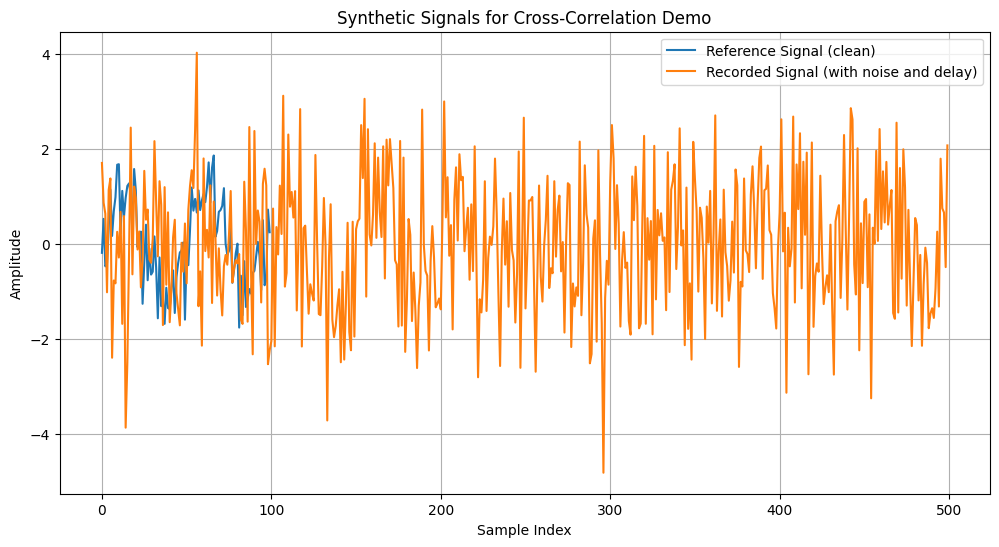

In [ ]:
# Generate a synthetic example

# 1. Create a reference signal (the signal we are looking for)
ref_len = 100  # Length of the reference signal
reference_signal = np.sin(np.linspace(0, 4 * np.pi, ref_len)) + 0.5 * np.random.randn(ref_len) # Add some noise to the reference itself

# 2. Create a longer recorded signal with the reference embedded and a delay
record_len = 500 # Length of the recorded signal
delay = 100       # Introduce a delay of 50 samples
noise_level = 1.25 # Level of random noise

recorded_signal = noise_level * np.random.randn(record_len) # Start with noise

# Embed the reference signal with the delay
# Ensure the reference signal fits within the recorded signal bounds after delay
if delay + ref_len <= record_len:
    recorded_signal[delay:delay + ref_len] += reference_signal
else:
    print("Warning: Reference signal plus delay exceeds recorded signal length. Adjusting parameters.")
    # Adjust delay or lengths if needed to make the example work

# 3. Plot the signals
plt.figure(figsize=(12, 6))
plt.plot(reference_signal, label='Reference Signal (clean)')
plt.plot(recorded_signal, label='Recorded Signal (with noise and delay)')
plt.title('Synthetic Signals for Cross-Correlation Demo')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

Actual delay introduced: 100 samples
Estimated delay from cross-correlation: -300 samples


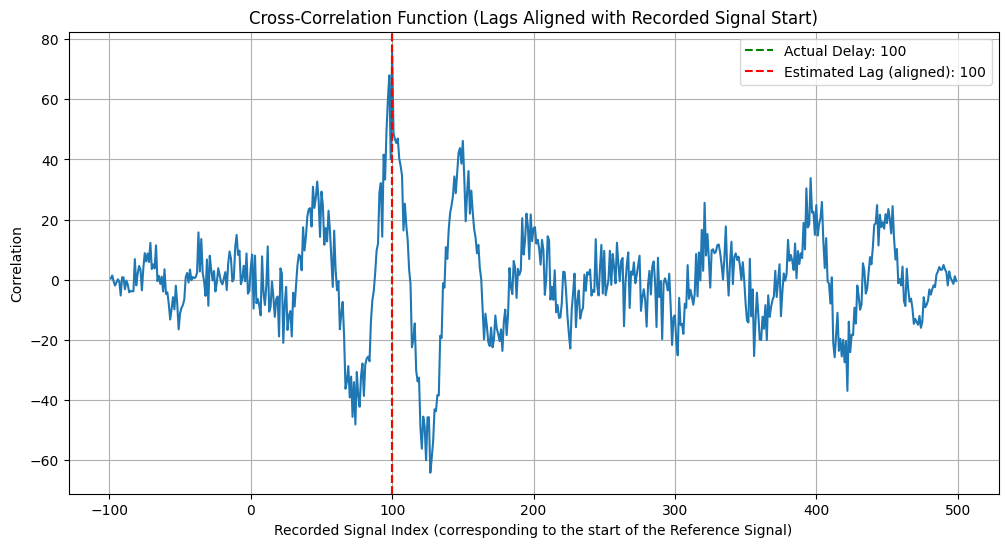

In [ ]:
# Perform Cross-Correlation

# Use np.correlate with mode='full' to get the full cross-correlation function
# The output length will be len(recorded_signal) + len(reference_signal) - 1
cross_corr = np.correlate(recorded_signal, reference_signal, mode='full')

# The lags array corresponds to the output of correlate
# The lags range from -(len(reference_signal) - 1) to (len(recorded_signal) - 1)
# Correct calculation for the lags array to match the 'full' mode output length
lags = np.arange(1 - record_len, ref_len)


# Find the index of the maximum correlation
max_corr_index = np.argmax(cross_corr)

# The estimated lag is the lag value at the index of maximum correlation
estimated_lag = lags[max_corr_index]

print(f"Actual delay introduced: {delay} samples")
print(f"Estimated delay from cross-correlation: {estimated_lag} samples")


# Plot the cross-correlation function
plt.figure(figsize=(12, 6))
# Plot against the time indices of the recorded signal for potentially more intuitive interpretation
plt.plot(lags + record_len -1 - (ref_len-1), cross_corr) # Adjust lags to align with recorded signal indices
plt.axvline(delay, color='g', linestyle='--', label=f'Actual Delay: {delay}') # Add a line for the actual delay
plt.axvline(estimated_lag + record_len -1 - (ref_len-1) , color='r', linestyle='--', label=f'Estimated Lag (aligned): {estimated_lag + record_len -1 - (ref_len-1)}') # Add a line for the estimated delay aligned
plt.title('Cross-Correlation Function (Lags Aligned with Recorded Signal Start)')
plt.xlabel('Recorded Signal Index (corresponding to the start of the Reference Signal)')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True)
plt.show()

**Interpretation:**

The peak in the cross-correlation plot indicates the time lag at which the recorded signal is most similar to the reference signal. In this synthetic example, the estimated lag should be very close to the actual delay we introduced. For real-world noisy signals, the peak might not be perfectly sharp, but the highest point still provides the best estimate of the time delay.

This technique is widely used in signal processing for tasks like synchronization, object detection, and channel estimation.

## Cross-Correlation for Time Lag Estimation

Cross-correlation can be used to determine the time delay between two signals. This is particularly useful when you're trying to find a known signal (the 'reference') within a longer, noisy recording.

The cross-correlation function will have a peak at the time lag where the two signals are most similar. The position of this peak tells us the estimated delay.

### Application: Detecting a Known Signal in Noise

Imagine you are trying to detect a specific sequence of pulses in a noisy communication channel, or find a particular sound signature in an audio recording. Cross-correlation can help you find when and where that known signal occurred in the noisy data.

**Interpretation:**

The peak in the cross-correlation plot indicates the time lag at which the recorded signal is most similar to the reference signal. In this synthetic example, the estimated lag should be very close to the actual delay we introduced. For real-world noisy signals, the peak might not be perfectly sharp, but the highest point still provides the best estimate of the time delay.

This technique is widely used in signal processing for tasks like synchronization, object detection, and channel estimation.

# Correlation Between Stock Returns

Let's analyze how different stock returns correlate with each other. This is a fundamental concept in portfolio diversification and pairs trading strategies.

**Reasoning**:
I need to read through the notebook from the perspective of an undergraduate student and identify confusing sections or areas needing more explanation. I will do this by examining each markdown and code cell sequentially, noting down observations about clarity, transitions, and potential difficulties for a beginner.

### Practical Use Cases for Cross-Correlation Time Lag Estimation

Beyond the synthetic example, cross-correlation for estimating time lag is used in various real-world scenarios that you might encounter or find relatable as an undergraduate student:

*   **Audio Processing (Think Music Production or Digital Audio Workstations):**
    *   **Echo Detection:** Imagine trying to remove an unwanted echo from a recording. You could use cross-correlation to find the delayed copies of the original sound and then subtract them.
    *   **Audio Alignment:** If you record the same performance with multiple microphones, cross-correlation can help you precisely align the audio tracks by finding the tiny time differences in when the sound arrived at each microphone.
    *   **Instrument Identification:** In a complex piece of music, you might use cross-correlation to find instances of a specific instrument's unique sound signature (the "reference signal") within the overall recording.
*   **Wireless Communication (Relevant to Computer Networks and Electrical Engineering):**
    *   **Signal Synchronization:** When your phone communicates with a cell tower, they need to be precisely synchronized in time. Cross-correlation helps the receiver find the start of a transmitted data packet by correlating it with a known preamble sequence.
    *   **GPS Receivers:** Your GPS device uses cross-correlation to measure the time it takes for signals from different satellites to arrive. This time delay is crucial for calculating your location.
*   **Image Processing (Useful in Computer Vision):**
    *   **Object Tracking:** In video analysis, you can use cross-correlation to track an object by finding where a small image of the object (the "reference") appears in subsequent frames.
    *   **Stereo Vision:** For 3D imaging, cross-correlation is used to find corresponding points in two images taken from slightly different viewpoints, which helps determine their depth.
*   **Biometrics (Finding Patterns):**
    *   **Fingerprint Matching:** While more complex algorithms exist, a simplified idea involves correlating patterns in fingerprint images to find matches.
*   **Finance (Connecting back to the notebook's theme):**
    *   **Lead-Lag Relationships:** As we touched on, cross-correlation between financial time series (like stock prices or economic indicators) can help identify if changes in one tend to precede changes in another. This is a basic technique explored in some trading strategies.

These are just a few examples, but they illustrate how the fundamental concept of finding a shifted version of one signal within another is applied across many exciting fields in computer science and beyond.



# Correlation Between Stock Returns

Let's analyze how different stock returns correlate with each other. This is a fundamental concept in portfolio diversification and pairs trading strategies.

Downloading...
From: https://drive.google.com/uc?id=1uBUC0aQSmTPdHFJ05fv6aZGu2MGw3EAW
To: /content/AAPL_data.csv
100% 67.2k/67.2k [00:00<00:00, 69.4MB/s]
Successfully downloaded AAPL_data.csv
Loaded AAPL data with 1259 price points and 1258 return values
Downloading...
From: https://drive.google.com/uc?id=1314rW_N3np8Mh8g74TPwSUBfI1I7lfA9
To: /content/MSFT_data.csv
100% 61.5k/61.5k [00:00<00:00, 49.9MB/s]
Successfully downloaded MSFT_data.csv
Loaded MSFT data with 1259 price points and 1258 return values
Downloading...
From: https://drive.google.com/uc?id=1fnjsjVdBqHRPHjMNST6i-bY2TFA7_iZM
To: /content/AMZN_data.csv
100% 65.2k/65.2k [00:00<00:00, 54.0MB/s]
Successfully downloaded AMZN_data.csv
Loaded AMZN data with 1259 price points and 1258 return values


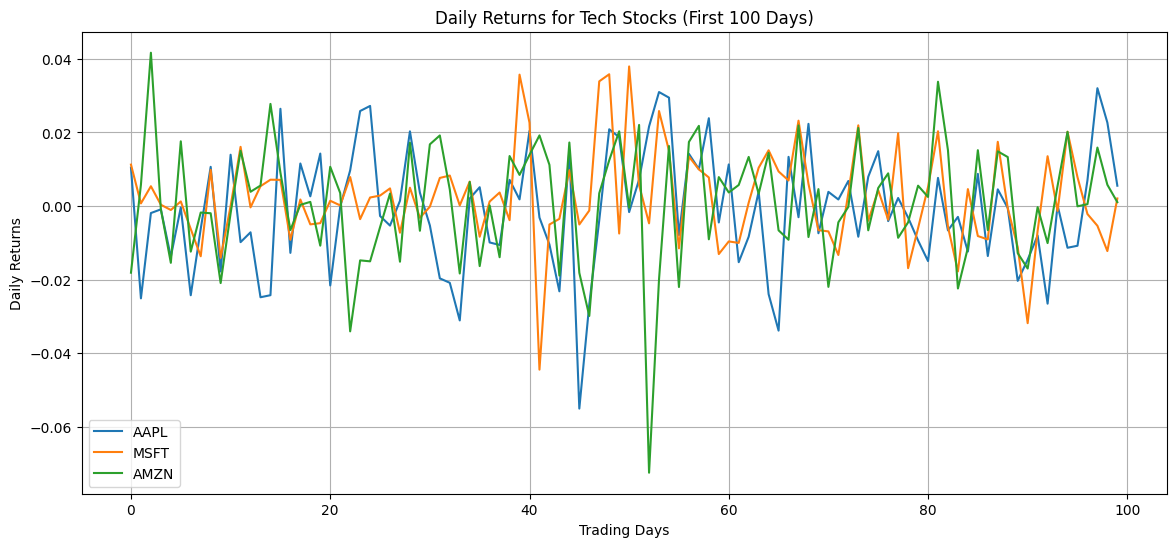

In [ ]:
# Function to calculate returns
def calculate_returns(prices):
    """Calculate daily returns from price data"""
    return np.diff(prices) / prices[:-1]

# Load stock data for three major tech companies
stock_files = {
    'AAPL': 'AAPL_data.csv',
    'MSFT': 'MSFT_data.csv',
    'AMZN': 'AMZN_data.csv'
}

# Dictionary to store returns for each stock
returns = {}

# Load each stock and calculate returns
for stock, filename in stock_files.items():
    file_id = file_ids.get(filename)
    if file_id:
        # Load the stock data
        prices, volumes = load_file_from_gdrive(file_id, filename, 'csv')

        # Calculate returns
        returns[stock] = calculate_returns(prices)
        print(f"Loaded {stock} data with {len(prices)} price points and {len(returns[stock])} return values")
    else:
        print(f"No file ID found for {filename}")

# Plot the returns for visual comparison
plt.figure(figsize=(14, 6))
for stock, ret_values in returns.items():
    plt.plot(ret_values[:100], label=stock)

plt.title("Daily Returns for Tech Stocks (First 100 Days)")
plt.xlabel("Trading Days")
plt.ylabel("Daily Returns")
plt.legend()
plt.grid(True)
plt.show()

Correlation Matrix:
AAPL-AAPL: 1.0000
AAPL-MSFT: 0.3666
AAPL-AMZN: 0.2877
MSFT-AAPL: 0.3666
MSFT-MSFT: 1.0000
MSFT-AMZN: 0.4027
AMZN-AAPL: 0.2877
AMZN-MSFT: 0.4027
AMZN-AMZN: 1.0000


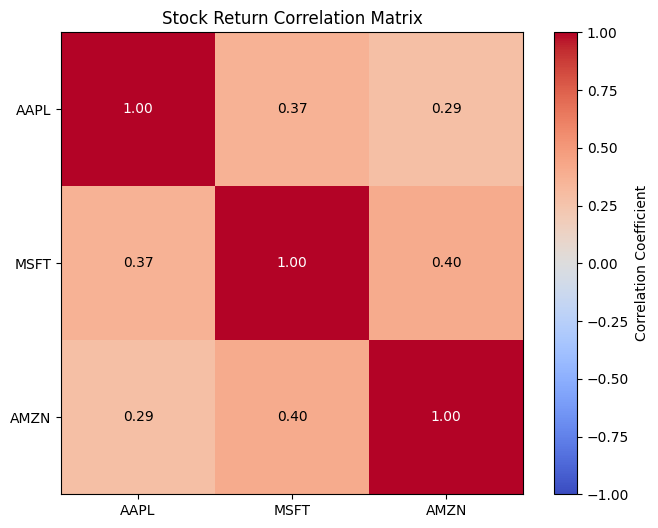


Financial Interpretation:
- Correlation values close to 1 indicate stocks that move together
- Values close to -1 indicate stocks that move in opposite directions
- Values near 0 indicate little relationship between stock movements
- For portfolio diversification, including stocks with low correlation reduces risk


In [ ]:
# Calculate correlation matrix between all stocks
stocks = list(returns.keys())
corr_matrix = np.zeros((len(stocks), len(stocks)))

for i, stock1 in enumerate(stocks):
    for j, stock2 in enumerate(stocks):
        # np.corrcoef returns a 2x2 matrix, we want the off-diagonal element
        corr_matrix[i, j] = np.corrcoef(returns[stock1], returns[stock2])[0, 1]

# Display the correlation matrix
print("Correlation Matrix:")
for i, stock1 in enumerate(stocks):
    for j, stock2 in enumerate(stocks):
        print(f"{stock1}-{stock2}: {corr_matrix[i, j]:.4f}")

# Create a more visual representation of the correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(np.arange(len(stocks)), stocks)
plt.yticks(np.arange(len(stocks)), stocks)

# Add correlation values in the cells
for i in range(len(stocks)):
    for j in range(len(stocks)):
        plt.text(j, i, f'{corr_matrix[i, j]:.2f}',
                 ha='center', va='center',
                 color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')

plt.title('Stock Return Correlation Matrix')
plt.show()

# Financial interpretation
print("\nFinancial Interpretation:")
print("- Correlation values close to 1 indicate stocks that move together")
print("- Values close to -1 indicate stocks that move in opposite directions")
print("- Values near 0 indicate little relationship between stock movements")
print("- For portfolio diversification, including stocks with low correlation reduces risk")

## Exercise: Cross-Correlation Between Stocks

Cross-correlation measures the similarity between two signals as a function of time lag between them.
This can help identify if one stock tends to lead or lag another in price movements.

Implement the cross-correlation between two stocks and find if there's a lead-lag relationship:
1. Use `np.correlate` with mode='full' to get the full correlation sequence
2. Find the index of maximum correlation
3. Calculate the time lag based on that index
4. Plot the cross-correlation function

In [ ]:
# Exercise solution here
# Example starter code:

stock1 = 'AAPL'
stock2 = 'MSFT'

# Implement cross-correlation
# cross_corr = ...

# Find lag with maximum correlation
# max_index = ...
# lag = ...

# Plot the cross-correlation
# plt.figure(figsize=(12, 5))
# plt.plot(...)

# Conclusion and Summary

In this notebook, we looked into advanced signal processing techniques and their applications in financial computation. We built upon basic filtering concepts to explore:

*   **Convolution:** We saw how convolution can be used for filtering, both in the context of audio processing (simulating venue acoustics) and financial analysis (implementing moving averages). We also compared the efficiency of time-domain and frequency-domain convolution.
*   **Window Functions:** We learned how different window functions can affect the characteristics of filters and explored various window types available in NumPy.
*   **Correlation:** We distinguished between correlation (measuring similarity at zero lag) and cross-correlation (measuring similarity as a function of time lag).
*   **Cross-Correlation for Time Lag Estimation:** We demonstrated how cross-correlation can be used to estimate the time delay between two signals, a technique with wide-ranging applications in various fields, including identifying patterns in noisy data.
*   **Financial Applications:** We applied these concepts to financial data, calculating moving averages using convolution and analyzing the correlation between different stock returns.

By understanding these signal processing techniques, you gain powerful tools for analyzing time-series data, identifying patterns, and building more sophisticated computational models in finance and beyond. The concepts of filtering, smoothing, and measuring signal similarity are fundamental and applicable to many areas of computer science and engineering.